# Local vs Global Ricci - Comparison (CIFAR-10)

Combines results from:
- `local_ricci_predictive_experiment_cifar10.ipynb` -> `summary.json` + `summary_k*.json`
- `global_ricci_predictive_experiment_cifar10.ipynb` -> `summary_global.json` + `summary_global_k*.json`

Produces:
1. A combined rank correlation table (Pearson / Spearman / Kendall on architecture ranks)
   for every (Ricci type, k) pair.
2. A side-by-side bar plot of all metrics with significance stars.

This notebook does NOT compute any Ricci coefficient or load activations directly --
it only reads the JSON summaries written by the two computation notebooks.


In [1]:
import os, json, glob
import numpy as np
from scipy.stats import pearsonr, spearmanr, kendalltau
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


def load_json(path, default):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return default


def save_json(path, obj):
    tmp = path + '.tmp'
    with open(tmp, 'w') as f:
        json.dump(obj, f, indent=2)
        f.flush()
        os.fsync(f.fileno())
    os.replace(tmp, path)


In [2]:
# -- Output directory (must match the LOCAL and GLOBAL notebooks!) --
DRIVE_BASE  = '/home/zkus/Desktop/izzettin-ismail-cihan/18052026'
OUTPUT_DIR  = os.path.join(DRIVE_BASE, 'local_vs_global_ricci_cifar10_v1')

# -- These constants are only used to label the "training-time k" rows in the table --
K_FRAC        = 0.05    # LOCAL training-time k_frac
K_GLOBAL_FRAC = 0.185   # GLOBAL training-time k_frac

if not os.path.isdir(OUTPUT_DIR):
    raise SystemExit(f'OUTPUT_DIR not found: {OUTPUT_DIR}\n'
                     f'  -> run the LOCAL and GLOBAL notebooks first.')

print(f'OUTPUT_DIR : {OUTPUT_DIR}')
print(f'  summary.json present        : '
      f'{os.path.exists(os.path.join(OUTPUT_DIR, "summary.json"))}')
print(f'  summary_global.json present : '
      f'{os.path.exists(os.path.join(OUTPUT_DIR, "summary_global.json"))}')


OUTPUT_DIR : /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1
  summary.json present        : True
  summary_global.json present : True


## Combined rank correlation table (LOCAL + GLOBAL Ricci)

- **Ricci rank**: 1 = most negative early Ricci value (strongest geometric signal).
- **Accuracy rank**: 1 = highest long-term accuracy.

The table aggregates:
- `summary.json`           (LOCAL training-time k)
- `summary_k*.json`        (LOCAL k-sweep)
- `summary_global.json`    (GLOBAL training-time k -- both raw `r` and Fisher `z`)
- `summary_global_k*.json` (GLOBAL k-sweep)


In [3]:
def rank_correlation(summary_data, ricci_key):
    arr   = np.array([r.get(ricci_key, np.nan) for r in summary_data], dtype=float)
    accs  = np.array([r['long_term_acc']        for r in summary_data], dtype=float)
    mask  = np.isfinite(arr) & np.isfinite(accs)
    if mask.sum() < 2:
        return None
    arr = arr[mask]; accs = accs[mask]
    n = len(arr)
    ricci_ranks = np.empty(n, dtype=int)
    ricci_ranks[np.argsort(arr)] = np.arange(1, n + 1)
    acc_ranks   = np.empty(n, dtype=int)
    acc_ranks[np.argsort(accs)[::-1]] = np.arange(1, n + 1)
    pr, pp = pearsonr(ricci_ranks, acc_ranks)
    sr, sp = spearmanr(ricci_ranks, acc_ranks)
    kt, kp = kendalltau(ricci_ranks, acc_ranks)
    return {'n': n,
            'pearson_r': float(pr),  'pearson_p':  float(pp),
            'spearman_r': float(sr), 'spearman_p': float(sp),
            'kendall_tau': float(kt),'kendall_p':   float(kp)}


rows = []

# ---- LOCAL ----
data = load_json(os.path.join(OUTPUT_DIR, 'summary.json'), [])
if len(data) >= 2:
    rc = rank_correlation(data, 'early_ricci_score')
    if rc is not None:
        rows.append({'ricci_type': 'local',
                     'k_label':    f'training k ({K_FRAC:.1%})', **rc})

for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'summary_k*.json'))):
    base = os.path.basename(path)
    if base.startswith('summary_global_'):
        continue
    tag = base.replace('summary_k', '').replace('.json', '')
    try:
        frac = int(tag) / 1000
    except ValueError:
        continue
    data = load_json(path, [])
    if len(data) < 2:
        continue
    rc = rank_correlation(data, 'early_ricci_score')
    if rc is not None:
        rows.append({'ricci_type': 'local', 'k_label': f'k={frac:.1%}', **rc})

# ---- GLOBAL (raw r AND Fisher z) ----
data = load_json(os.path.join(OUTPUT_DIR, 'summary_global.json'), [])
if len(data) >= 2:
    rc_r = rank_correlation(data, 'early_global_ricci_r')
    rc_z = rank_correlation(data, 'early_global_ricci_z')
    if rc_r is not None:
        rows.append({'ricci_type': 'global_r',
                     'k_label':    f'training k ({K_GLOBAL_FRAC:.1%})', **rc_r})
    if rc_z is not None:
        rows.append({'ricci_type': 'global_z',
                     'k_label':    f'training k ({K_GLOBAL_FRAC:.1%})', **rc_z})

for path in sorted(glob.glob(os.path.join(OUTPUT_DIR, 'summary_global_k*.json'))):
    tag = os.path.basename(path).replace('summary_global_k', '').replace('.json', '')
    try:
        frac = int(tag) / 1000
    except ValueError:
        continue
    data = load_json(path, [])
    if len(data) < 2:
        continue
    rc_r = rank_correlation(data, 'early_global_ricci_r')
    rc_z = rank_correlation(data, 'early_global_ricci_z')
    if rc_r is not None:
        rows.append({'ricci_type': 'global_r', 'k_label': f'k={frac:.1%}', **rc_r})
    if rc_z is not None:
        rows.append({'ricci_type': 'global_z', 'k_label': f'k={frac:.1%}', **rc_z})

# ---- Print + save ----
header = (f"  {'type':<10} {'k':<24} {'n':>4}  {'Pearson r':>10}  {'p_pear':>8}  "
          f"{'Spearman r':>11}  {'p_spear':>8}  "
          f"{'Kendall tau':>12}  {'p_kend':>8}")
print(header); print('-' * len(header))
for row in rows:
    print(f"  {row['ricci_type']:<10} {row['k_label']:<24} {row['n']:>4}  "
          f"{row['pearson_r']:>+10.4f}  {row['pearson_p']:>8.4f}  "
          f"{row['spearman_r']:>+11.4f}  {row['spearman_p']:>8.4f}  "
          f"{row['kendall_tau']:>+12.4f}  {row['kendall_p']:>8.4f}")
if not rows:
    print('  (no summaries found yet -- run LOCAL and GLOBAL notebooks first)')

save_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table.json'), rows)
print(f"\nSaved -> {os.path.join(OUTPUT_DIR, 'rank_correlation_table.json')}")
print()
print('Positive r/rho/tau: more negative early Ricci predicts higher accuracy.')


  type       k                           n   Pearson r    p_pear   Spearman r   p_spear   Kendall tau    p_kend
---------------------------------------------------------------------------------------------------------------
  local      training k (5.0%)          45     +0.2572    0.0881      +0.2572    0.0881       +0.1636    0.1130
  local      k=3.0%                     45     +0.2111    0.1640      +0.2111    0.1640       +0.1354    0.1899
  local      k=7.0%                     45     +0.2462    0.1030      +0.2462    0.1030       +0.1576    0.1270
  global_r   training k (18.5%)         45     -0.3829    0.0094      -0.3829    0.0094       -0.2566    0.0130
  global_z   training k (18.5%)         40     -0.4867    0.0015      -0.4867    0.0015       -0.3205    0.0036
  global_r   k=12.5%                    45     -0.4406    0.0025      -0.4406    0.0025       -0.3071    0.0029
  global_z   k=12.5%                    40     -0.5390    0.0003      -0.5390    0.0003       -0.3564   

## Local vs Global Ricci -- correlation comparison plot

3 subplots (Pearson / Spearman / Kendall), one bar per (Ricci type, k) row.
Local = blue, Global raw r = red, Global Fisher z = green.
Significance stars: * p<0.05, ** p<0.01, *** p<0.001.


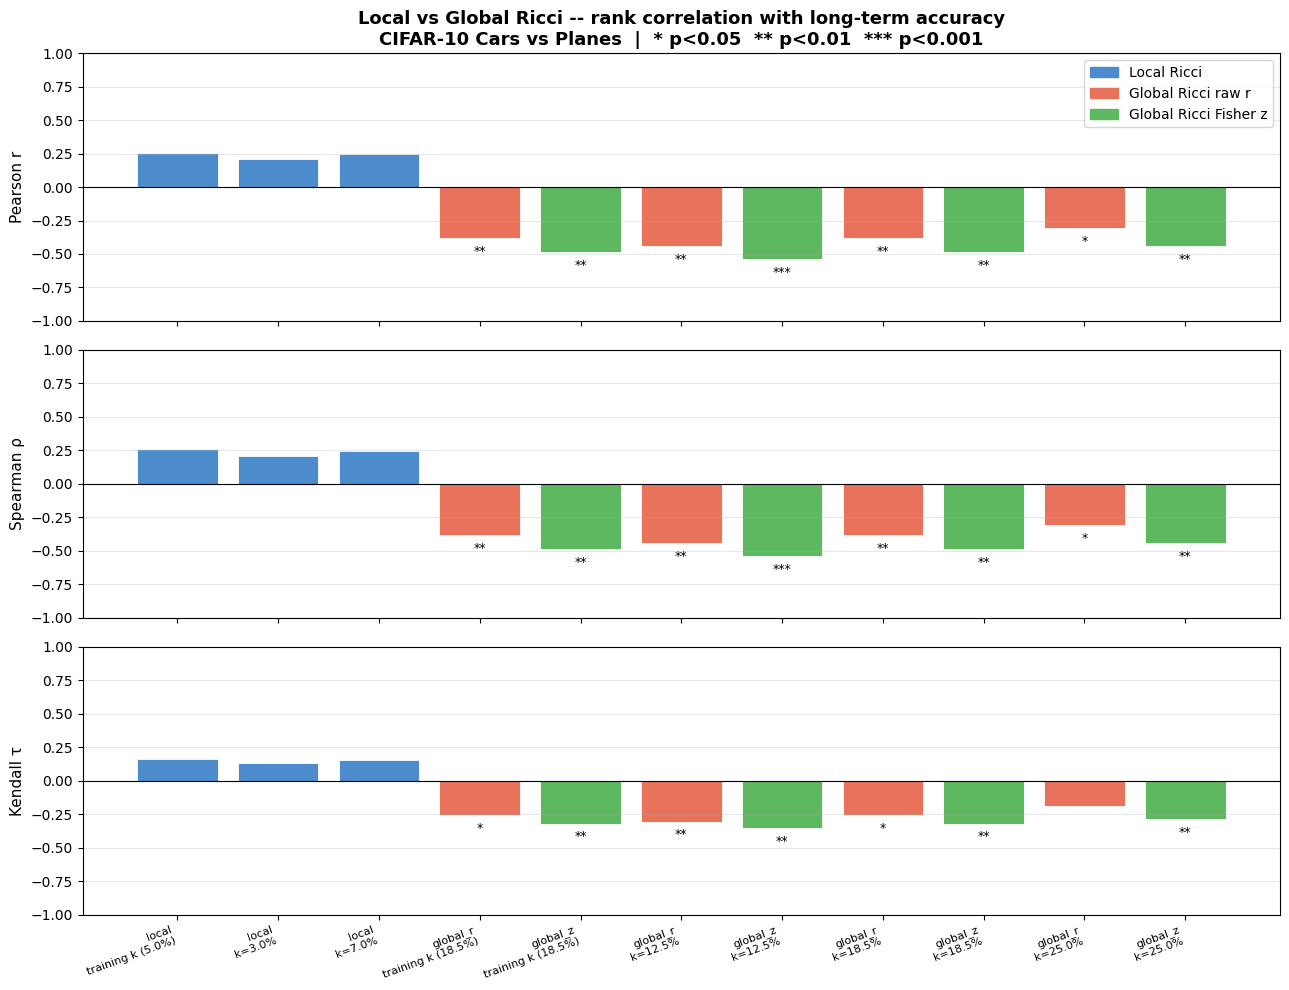

Saved -> /home/zkus/Desktop/izzettin-ismail-cihan/18052026/local_vs_global_ricci_cifar10_v1/correlation_comparison_local_vs_global.png


In [4]:
rows = load_json(os.path.join(OUTPUT_DIR, 'rank_correlation_table.json'), [])
if not rows:
    print('Run the rank correlation table cell first.')
else:
    def _stars(p):
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return ''

    type_color = {'local':    '#4C8BCC',
                  'global_r': '#E8735A',
                  'global_z': '#5DB860'}
    type_label = {'local':    'Local Ricci',
                  'global_r': 'Global Ricci raw r',
                  'global_z': 'Global Ricci Fisher z'}

    fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
    metrics = [('pearson_r',  'pearson_p',  'Pearson r'),
               ('spearman_r', 'spearman_p', 'Spearman \u03c1'),
               ('kendall_tau','kendall_p',  'Kendall \u03c4')]

    x = np.arange(len(rows))
    xticklabels = [f"{r['ricci_type']}\n{r['k_label']}" for r in rows]

    for ax, (mkey, pkey, mlabel) in zip(axes, metrics):
        vals  = [r[mkey] for r in rows]
        pvals = [r[pkey] for r in rows]
        cols  = [type_color[r['ricci_type']] for r in rows]
        bars  = ax.bar(x, vals, color=cols, edgecolor='white', linewidth=0.6)
        for bar, p in zip(bars, pvals):
            s = _stars(p)
            if s:
                offset = 0.02 if bar.get_height() >= 0 else -0.05
                ax.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + offset, s,
                        ha='center', va='bottom' if bar.get_height() >= 0 else 'top',
                        fontsize=9)
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_ylabel(mlabel, fontsize=11)
        ax.set_ylim(-1, 1); ax.grid(axis='y', alpha=0.3)

    axes[-1].set_xticks(x)
    axes[-1].set_xticklabels(xticklabels, fontsize=8, rotation=20, ha='right')

    handles = [mpatches.Patch(color=type_color[t], label=type_label[t])
               for t in ['local', 'global_r', 'global_z']]
    axes[0].legend(handles=handles, fontsize=10, loc='upper right')
    axes[0].set_title('Local vs Global Ricci -- rank correlation with long-term accuracy\n'
                      'CIFAR-10 Cars vs Planes  |  * p<0.05  ** p<0.01  *** p<0.001',
                      fontsize=13, fontweight='bold')

    plt.tight_layout()
    save_path = os.path.join(OUTPUT_DIR, 'correlation_comparison_local_vs_global.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Saved -> {save_path}')
